Le script est fait pour être utilisé sur le dossier data donc avec déjà les IRMs réorganisé par patient puis par période. De plus, il se base sur des IRMs compressé (.nii.gz)

In [1]:
conda env list

# conda environments:
#
base                     C:\ProgramData\anaconda3
CORRAU_RESIMET           C:\ProgramData\anaconda3\envs\CORRAU_RESIMET
pytorch                  C:\ProgramData\anaconda3\envs\pytorch
tensorflow               C:\ProgramData\anaconda3\envs\tensorflow
                         C:\Users\C101065\.conda\envs\FL
                         C:\Users\C101065\.conda\envs\xAI
                      *  C:\Users\C101065\.conda\envs\xAIRegistration
                         C:\Users\JAUCYR\.conda\envs\JAUCYR_DOSY
                         C:\Users\M1074839\.conda\envs\ants


Note: you may need to restart the kernel to use updated packages.


# Process all the dataset

In [2]:
from antspynet.utilities import brain_extraction
import ants
import os
from tqdm import tqdm
import nibabel as nib

In [29]:
dir_to_processed = '../../SAVE_RECAL_COMPRESS'
dir_output = '../../SAVE_RECAL_COMPRESS_skull_strip/'

patients = os.listdir(dir_to_processed)
for patient in tqdm(patients):
    if patient in os.listdir(dir_output): continue # brain already extract for this patient
    os.makedirs(os.path.join(dir_output, patient), exist_ok=True)
    filename_p0_t1gd = f"{patient}_p0_t1gd.nii.gz"
    assert filename_p0_t1gd in os.listdir(os.path.join(dir_to_processed, patient)) # we check that the p0_t1gd mri exist

    mri_p0_t1gd = ants.image_read(os.path.join(dir_to_processed, patient, filename_p0_t1gd))
    brain_mask = brain_extraction(mri_p0_t1gd, modality="t1")

    os.makedirs(os.path.join(dir_output, patient), exist_ok=True)
    mris = os.listdir(os.path.join(dir_to_processed, patient))
    for mri in mris:
        mri_img = ants.image_read(os.path.join(dir_to_processed, patient, mri))
        mri_shape = mri_img.shape
        brain_extracted_mri = mri_img * brain_mask
        ants.image_write(brain_extracted_mri, os.path.join(dir_output, patient, mri))

100%|████████████████████████████████████████████████████████████████████████████████| 265/265 [00:24<00:00, 10.67it/s]


In [7]:
os.path.join(dir_to_processed, filename_t0_t1gd)

'../../6/t0/6_t0_t1gd.nii.gz'

In [20]:
os.listdir('../../SAVE_RECAL_COMPRESS')

['197702515',
 '197804332',
 '198001254',
 '198402703',
 '198403760',
 '198500727',
 '198701234',
 '198706717',
 '198707964',
 '198904674',
 '199101363',
 '199102559',
 '199700265',
 '199703550',
 '200104092',
 '200302646',
 '200305840',
 '200306555',
 '200505736',
 '200604793',
 '200700090',
 '200802928',
 '200901400',
 '200907467',
 '201000643',
 '201003140',
 '201205035',
 '201301690',
 '201302754',
 '201307888',
 '201307958',
 '201401139',
 '201404690',
 '201409034',
 '201504146',
 '201505585',
 '201508778',
 '201604298',
 '201604872',
 '201707379',
 '201708099',
 '201708236',
 '201800300',
 '201801129',
 '201801130',
 '201801132',
 '201802076',
 '201802077',
 '201802089',
 '201802337',
 '201802602',
 '201802691',
 '201802955',
 '201803631',
 '201803807',
 '201804687',
 '201804709',
 '201804710',
 '201805161',
 '201805309',
 '201806338',
 '201806547',
 '201806548',
 '201806549',
 '201806931',
 '201806932',
 '201807630',
 '201807742',
 '201808095',
 '201808096',
 '201808097',
 '2018

In [9]:
os.listdir(dir_to_processed)

FileNotFoundError: [WinError 3] Le chemin d’accès spécifié est introuvable: '../../6/t0/'

In [21]:
dir_to_processed = '../../SAVE_RECAL_COMPRESS/198500727'
filename_t0_t1gd = '198500727_p0_t1gd.nii.gz'

mri_t0_t1gd = ants.image_read(os.path.join(dir_to_processed, filename_t0_t1gd))
brain_mask = brain_extraction(mri_t0_t1gd, modality="t1")


In [22]:
brain_mask[:,:,114].shape

(512, 512)

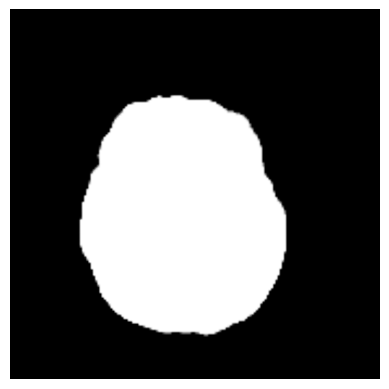

In [23]:
brain_mask[:,:,114].plot()

# Process a specific patient

In [3]:
from antspynet.utilities import brain_extraction
import ants
import os
from tqdm import tqdm
import nibabel as nib

In [4]:
dir_to_processed = '../new_ct_rt_gtv/add_8_slices/mri'
dir_output = '../new_ct_rt_gtv/add_8_slices/mri_processed'
os.makedirs(dir_output, exist_ok=True)

files = os.listdir(dir_to_processed)
for file in tqdm(files):
    patient = file.split('_')[0]
    print(patient)
    filename_p0_t1gd = f"{patient}_p0_t1gd.nii.gz"
    assert filename_p0_t1gd in os.listdir(dir_to_processed) # we check that the p0_t1gd mri exist

    mri_p0_t1gd = ants.image_read(os.path.join(dir_to_processed, filename_p0_t1gd))
    brain_mask = brain_extraction(mri_p0_t1gd, modality="t1")

    mris = os.listdir(dir_to_processed)
    for mri in mris:
        mri_img = ants.image_read(os.path.join(dir_to_processed, mri))
        mri_shape = mri_img.shape
        brain_extracted_mri = mri_img * brain_mask
        ants.image_write(brain_extracted_mri, os.path.join(dir_output, mri))

  0%|                                                                                            | 0/3 [00:00<?, ?it/s]

198904674


 33%|████████████████████████████                                                        | 1/3 [00:12<00:25, 12.53s/it]

198904674


 67%|████████████████████████████████████████████████████████                            | 2/3 [00:24<00:12, 12.11s/it]

198904674


100%|████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:36<00:00, 12.05s/it]
